In [ ]:
Instance-based Learning (Lazy Learning)

    KNN doesn’t build a model explicitly during training.
    It stores all training data and performs computation only during prediction.
    Hence called lazy learner.

Distance Metrics

    Distance measure determines how neighbors are found.
    Common metrics:
        Euclidean distance (most common)
        Manhattan distance
        Minkowski distance
        Cosine similarity (less common in classic KNN)
    Choice of metric affects the performance based on data.

Choosing K (Number of Neighbors)

    K is a hyperparameter controlling the smoothness of decision boundary.
    Small K (e.g., 1) → low bias, high variance → prone to overfitting.
    Large K → high bias, low variance → may underfit.
    K is usually chosen using cross-validation.

Majority Voting (Classification)

    Class assigned by majority vote of K nearest neighbors.
    Can use weighted voting (weight neighbors by inverse distan

Distance Weighting

    Instead of equal voting, closer neighbors get higher weight.
    Common schemes:
        Inverse distance weighting
        Gaussian kernel weighting

KNN for Regression

    Instead of majority vote, average (or weighted average) of neighbors’ target values.


In [ ]:
import numpy as np
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier

# Training data (2D points)
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7],
    [8, 6]
])
y_train = np.array(['A', 'A', 'A', 'B', 'B', 'B'])

# Test point
x_test = np.array([5, 5])


In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, x_test, k=3):
    distances = [euclidean_distance(x_test, x) for x in X_train]
    k_indices = np.argsort(distances)[:k]
    k_nearest_labels = y_train[k_indices]
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

manual_pred = knn_predict(X_train, y_train, x_test, k=3)
print(f"Manual KNN prediction for {x_test}: {manual_pred}")


Manual KNN prediction for [5 5]: B


In [ ]:
# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Fit on training data
knn.fit(X_train, y_train)

# Predict on the same test point
sklearn_pred = knn.predict([x_test])[0]
print(f"scikit-learn KNN prediction for {x_test}: {sklearn_pred}")


scikit-learn KNN prediction for [5 5]: B


In [ ]:
# some examples
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
# multi class
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Load Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6889

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.86        18
           1       0.67      0.71      0.69        17
           2       0.40      0.40      0.40        10

    accuracy                           0.69        45
   macro avg       0.65      0.65      0.65        45
weighted avg       0.69      0.69      0.69        45



Mean Squared Error: 0.0460


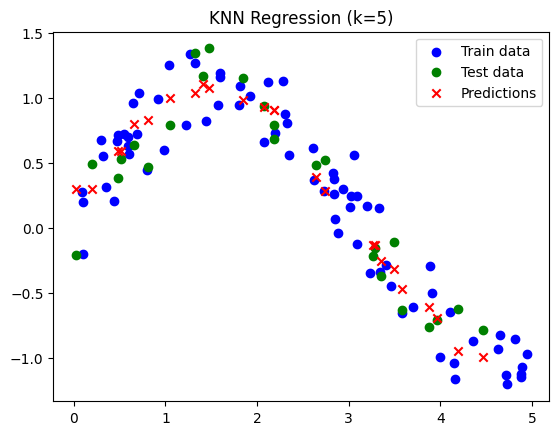

In [ ]:
# KNN regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate synthetic data
np.random.seed(0)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # noisy sine wave

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Initialize KNN regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

# Predict on test set
y_pred = knn_reg.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# Plot results
plt.scatter(X_train, y_train, label='Train data', color='blue')
plt.scatter(X_test, y_test, label='Test data', color='green')
plt.scatter(X_test, y_pred, label='Predictions', color='red', marker='x')
plt.title("KNN Regression (k=5)")
plt.legend()
plt.show()


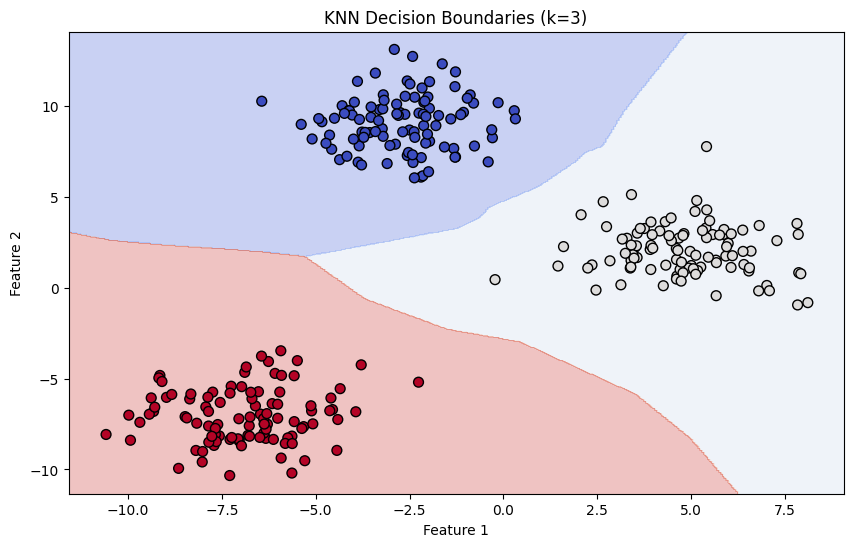

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier

# Create synthetic 2D data with 3 classes
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=1.5)

# Create and fit KNN classifier
knn = KNeighborsClassifier(n_neighbors=1) #Increasing k smooths the boundaries, decreasing overfitting.
knn.fit(X, y)
# Boundaries are non-linear and depend on local neighborhoods.


# Define mesh grid boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict on mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary with training points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title("KNN Decision Boundaries (k=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
# Voronoi Diagram to Visualize KNN Decision Boundaries
#    Remember this, -----------------------------equally distant---------------------------

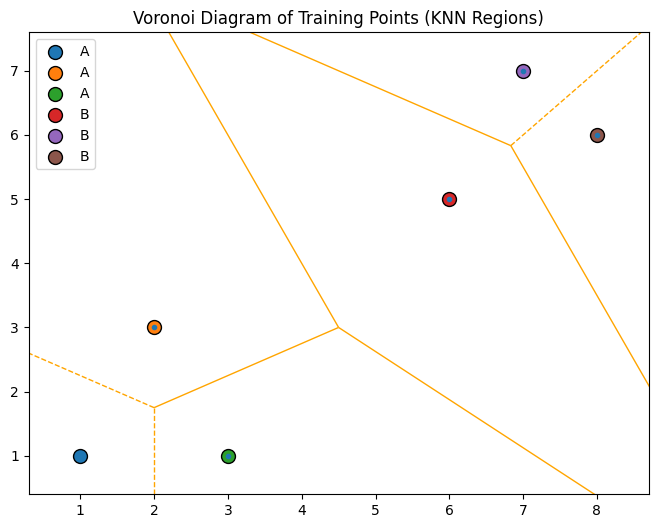

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

# Sample 2D points with class labels
points = np.array([[1, 1], [2, 3], [3, 1], [6, 5], [7, 7], [8, 6]])
labels = ['A', 'A', 'A', 'B', 'B', 'B']

# Plot the points
plt.figure(figsize=(8,6))
for point, label in zip(points, labels):
    plt.scatter(point[0], point[1], label=label, s=100, edgecolors='k')

# Compute Voronoi diagram
vor = Voronoi(points)

# Plot Voronoi diagram
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='orange')

plt.title("Voronoi Diagram of Training Points (KNN Regions)")
plt.legend()
plt.show()


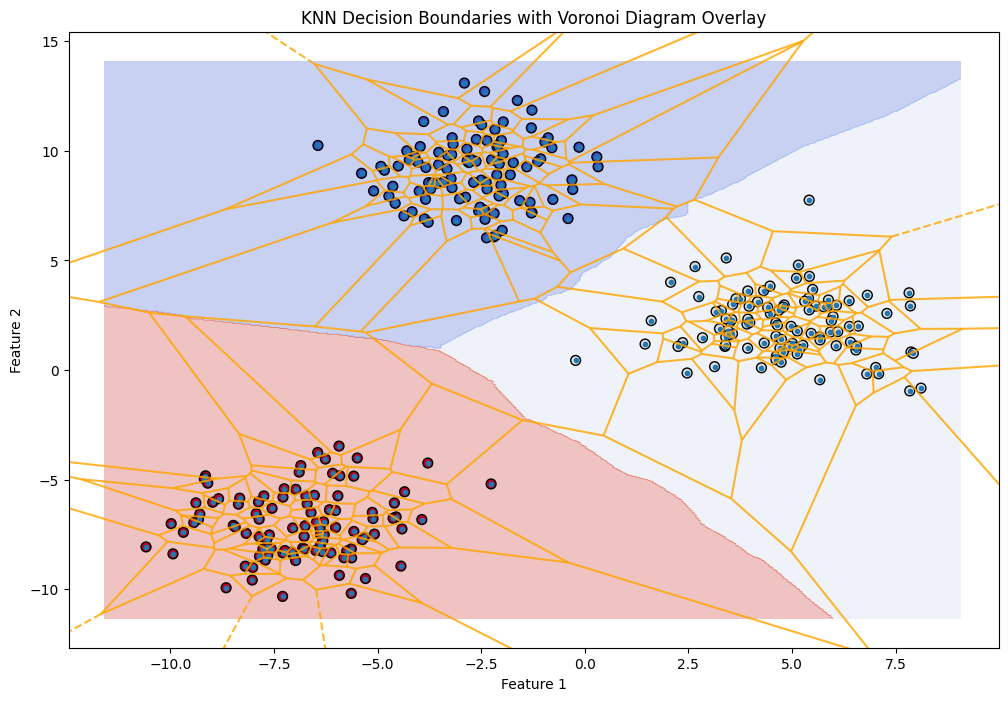

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import Voronoi, voronoi_plot_2d

# Create synthetic 2D data with 3 classes
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=1.5)

# Create and fit KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

# Define mesh grid boundaries for decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict on mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Scatter plot of points colored by class
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.coolwarm, edgecolor='k')

# Compute Voronoi diagram on training points
vor = Voronoi(X)

# Plot Voronoi diagram edges on top
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='orange', line_width=1.5, line_alpha=0.8)

plt.title("KNN Decision Boundaries with Voronoi Diagram Overlay")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


<!--- This show Voronoi regions that represent the areas closest to each training point.
These regions help visualize how KNN assigns classes based on proximity.

The Voronoi regions (orange/yellow lines) partition the space closest to each training point.
The KNN decision boundaries are smoother because they consider the k nearest neighbors (not just the closest).
This helps understand how KNN uses local neighborhoods to classify. -->


In [ ]:
# Each colored region in the Voronoi diagram corresponds to the area closest to a training point.
# In KNN with k=1, a test point inside that region would be classified with that training point's label.
# With larger k, decision boundaries smooth out by considering neighbors.